# Analyse Bronze RTE
Visualisation du fichier parquet agrégé des données annuelles définitives RTE.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 0
sns.set_theme(style="whitegrid")

parquet_path = (Path.cwd().parent / "data" / "bronze" / "rte_annuel_definitif.parquet").resolve()
print(f"Parquet: {parquet_path}")

if not parquet_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable: {parquet_path}\n"
        "Exécute d'abord src/scripts/raw_to_bronze_rte.py"
    )

df = pd.read_parquet(parquet_path)
print(f"Shape: {df.shape}")
display(df.head())

Parquet: /home/camille/code/Camille9999/EPSI/M2/EPSI-M2_MSPR/src/data/bronze/rte_annuel_definitif.parquet
Shape: (455904, 41)


,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,Taux de Co2,Ech. comm. Angleterre,Ech. comm. Espagne,Ech. comm. Italie,Ech. comm. Suisse,timestamp,source_year,Ech. comm. Allemagne-Belgique,Fioul - TAC,Fioul - Cogén.,Fioul - Autres,Gaz - TAC,Gaz - Cogén.,Gaz - CCG,Gaz - Autres,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre
0,Données définitives,2012-02-07,19:15,100005,99500,99700,5330,4609,7611,59040,3852,0,12376,-3,635,6554,127,1804,1000,667,-298,3766,2026-04-03 10:00:05,2012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Données définitives,2012-02-07,19:30,100005,99000,99200,5330,4609,7611,59040,3852,0,12376,-3,635,6554,127,1804,1000,667,-298,3766,2026-04-03 10:00:05,2012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Données définitives,2012-02-08,09:45,100014,98300,99650,5433,5185,7787,59308,2309,358,11764,-3,632,7242,135,2000,500,321,27,4399,2026-04-03 10:00:14,2012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Données définitives,2012-02-08,10:00,100014,98300,99600,5433,5185,7787,59308,2309,358,11764,-3,632,7242,135,2000,500,321,27,4399,2026-04-03 10:00:14,2012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Données définitives,2012-02-07,18:45,100430,98950,99000,5361,4768,7636,59034,3818,0,12065,-3,633,7116,129,1804,1000,667,-298,3766,2026-04-03 10:04:30,2012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [5]:
production_cols = ["Fioul", "Charbon", "Gaz", "Nucléaire", "Eolien", "Solaire", "Hydraulique", "Pompage", "Bioénergies"]
df["Production"] = df[production_cols].sum(axis=1)

In [ ]:
df_info = pd.DataFrame({
    "colonne": df.columns,
    "dtype": [str(dt) for dt in df.dtypes],
    "nb_manquants": df.isna().sum().values,
    "pct_manquants": (df.isna().mean().values * 100).round(2),
})

print("Aperçu du schéma et des valeurs manquantes:")
display(df_info.sort_values(["pct_manquants", "colonne"], ascending=[False, True]).head(20))

Aperçu du schéma et des valeurs manquantes:


,colonne,dtype,nb_manquants,pct_manquants
22,timestamp,datetime64[us],455896,100.00
37,Bioénergies - Biogaz,Int64,315652,69.24
39,Déstockage batterie,Int64,315652,69.24
40,Eolien terrestre,Int64,315652,69.24
38,Stockage batterie,Int64,315652,69.24
36,Bioénergies - Biomasse,Int64,35148,7.71
35,Bioénergies - Déchets,Int64,35148,7.71
24,Ech. comm. Allemagne-Belgique,Int64,35148,7.71
27,Fioul - Autres,Int64,35148,7.71
26,Fioul - Cogén.,Int64,35148,7.71


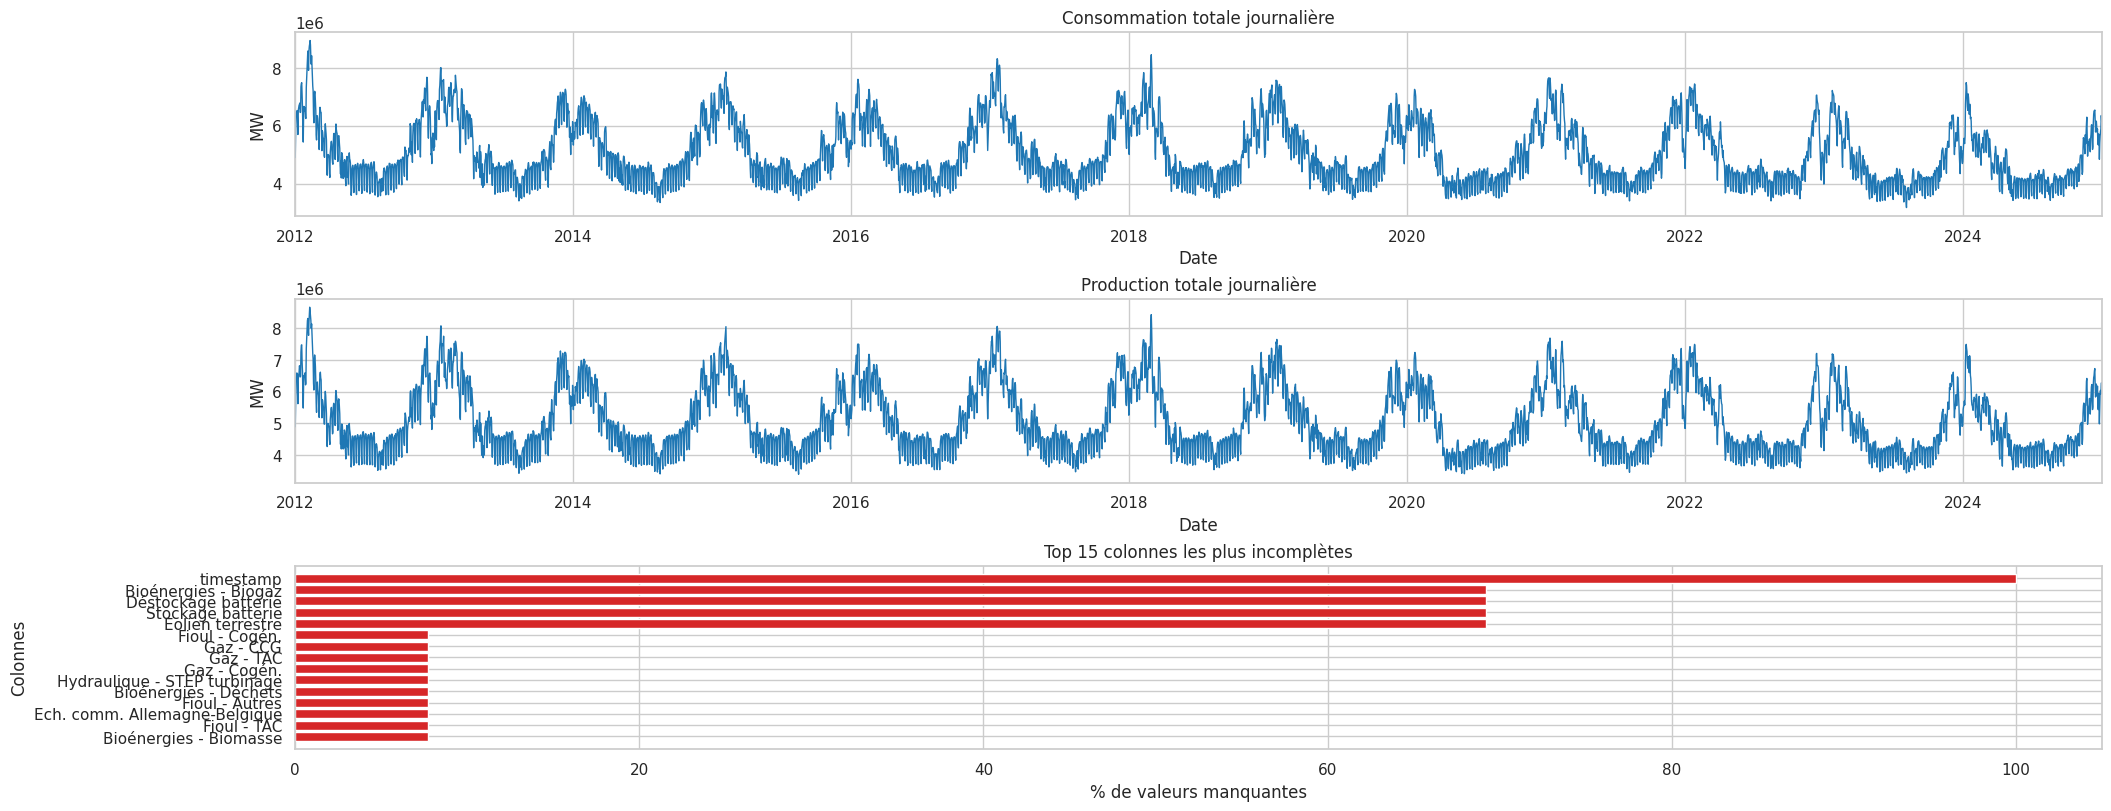

In [8]:
plot_df = df.copy()
plot_df["Nature"] = pd.to_datetime(plot_df["Nature"], errors="coerce")
plot_df["Consommation"] = pd.to_numeric(plot_df["Consommation"], errors="coerce")
plot_df = plot_df.dropna(subset=["Nature"]).sort_values("Nature")

# Moyenne journalière pour lisibilité
daily_conso = (
    plot_df.set_index("Nature")["Consommation"]
    .resample("D")
    .sum()
    .rename("Consommation_totale")
)

daily_prod = (
    plot_df.set_index("Nature")["Production"]
    .resample("D")
    .sum()
    .rename("Production_totale")
)

fig, axes = plt.subplots(3, 1, figsize=(21, 8), constrained_layout=True)

daily_conso.plot(ax=axes[0], color="#1f77b4", linewidth=1.0)
axes[0].set_title("Consommation totale journalière")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("MW")

missing_top = (
    df.isna().mean()
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)
)

daily_prod.plot(ax=axes[1], color="#1f77b4", linewidth=1.0)
axes[1].set_title("Production totale journalière")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MW")

axes[2].barh(missing_top.index, missing_top.values * 100, color="#d62728")
axes[2].set_title("Top 15 colonnes les plus incomplètes")
axes[2].set_xlabel("% de valeurs manquantes")
axes[2].set_ylabel("Colonnes")

plt.show()